In [5]:
import jax_galsim as galsim
import matplotlib.pyplot as plt

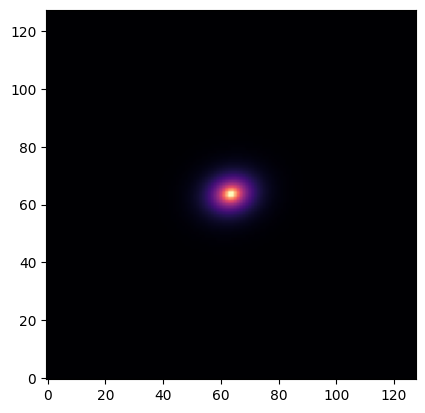

In [32]:
# Spergel profile parameters
nu = .5
hlr = 1.
flux = 50.0 * 1e-3

# Galaxy parameters
e1 = 0.2
e2 = 0.1

# Image parameters
Npx = 128
pixel_scale = 0.15 # arcsec/pixel

gal = galsim.Spergel(nu=nu, half_light_radius=hlr, flux=flux)
gal = gal.shear(e1=e1, e2=e2)
image = gal.drawImage(nx=Npx, ny=Npx, scale=pixel_scale)

# Plot the image
plt.imshow(image.array, origin='lower', cmap='magma')

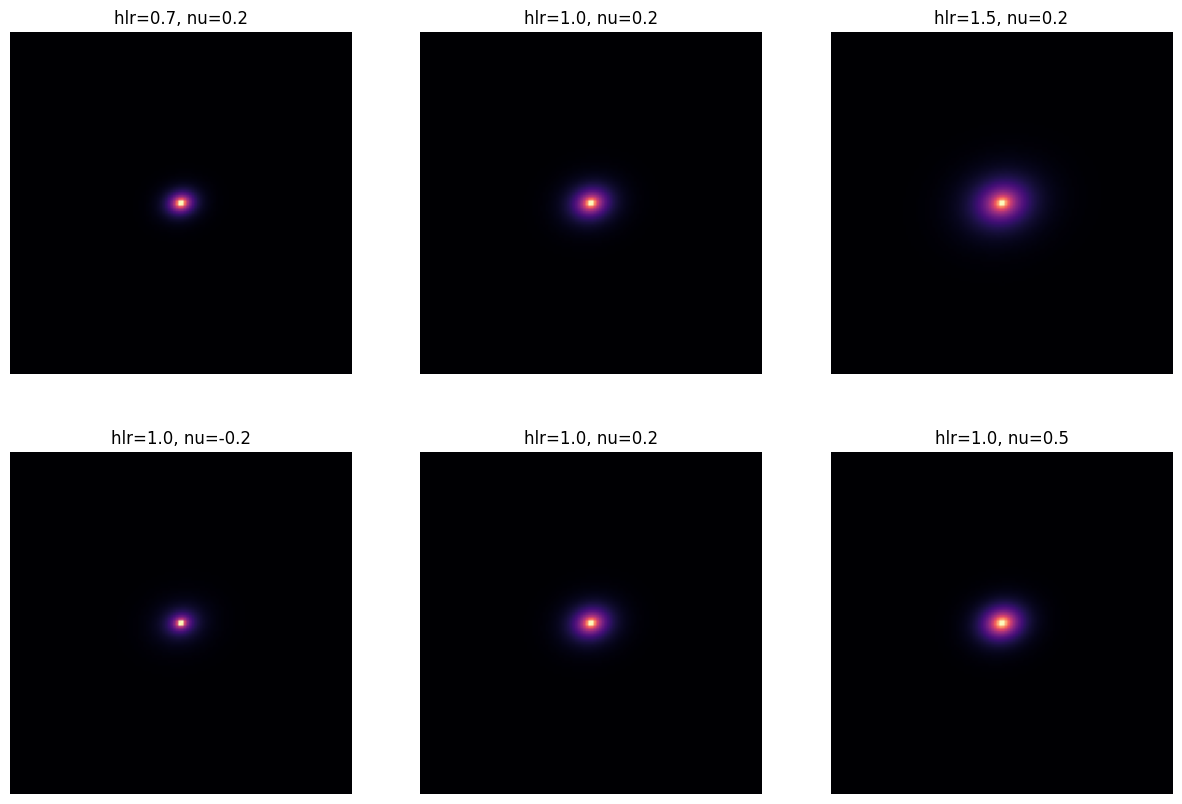

In [31]:
# Create plot of 2x3 grid showing 6 different profiles.
# Use hlr = 0.5, 1.0, 1.5 and nu = -0.5, 0.0, 0.5
# Use the middle value of hlr and nu as the default for the other parameters when varying one of them.

hlr_values = [0.7, 1.0, 1.5]
nu_values = [-0.2, 0.2, 0.5]

fig, axs = plt.subplots(2, 3, figsize=(15, 10))
for i, hlr in enumerate(hlr_values):
    gal = galsim.Spergel(nu=nu_values[1], half_light_radius=hlr, flux=flux)
    gal = gal.shear(e1=e1, e2=e2)
    image = gal.drawImage(nx=Npx, ny=Npx, scale=pixel_scale)
    axs[0, i].imshow(image.array, origin='lower', cmap='magma')
    axs[0, i].set_title(f'hlr={hlr}, nu={nu_values[1]}')
    axs[0, i].axis('off')
for i, nu in enumerate(nu_values):
    gal = galsim.Spergel(nu=nu, half_light_radius=hlr_values[1], flux=flux)
    gal = gal.shear(e1=e1, e2=e2)
    image = gal.drawImage(nx=Npx, ny=Npx, scale=pixel_scale)
    axs[1, i].imshow(image.array, origin='lower', cmap='magma')
    axs[1, i].set_title(f'hlr={hlr_values[1]}, nu={nu}')
    axs[1, i].axis('off')

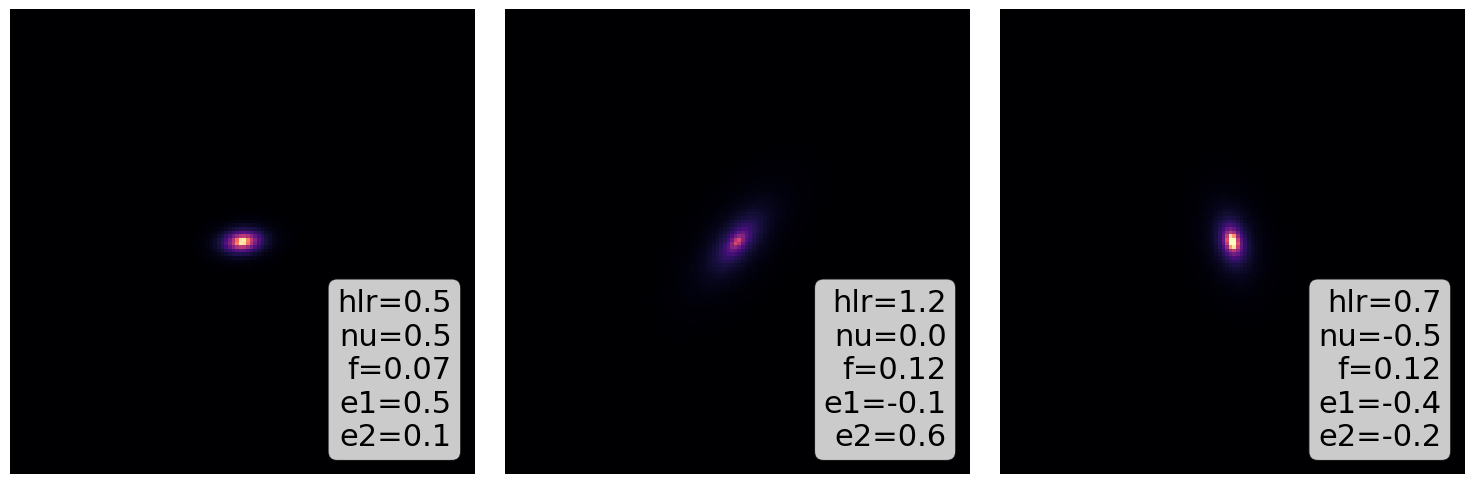

In [69]:
# Create a plot of three example galaxies with different parameters
gal1_params = {'nu': 0.5, 'hlr': .5, 'flux': 70.0 * 1e-3, 'e1': 0.5, 'e2': 0.1}
gal2_params = {'nu': 0.0, 'hlr': 1.2, 'flux': 120.0 * 1e-3, 'e1': -0.1, 'e2': 0.6}
gal3_params = {'nu': -0.5, 'hlr': .7, 'flux': 120 * 1e-3, 'e1': -0.4, 'e2': -0.2}

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for i, params in enumerate([gal1_params, gal2_params, gal3_params]):
    gal = galsim.Spergel(nu=params['nu'], half_light_radius=params['hlr'], flux=params['flux'])
    gal = gal.shear(e1=params['e1'], e2=params['e2'])
    image = gal.drawImage(nx=Npx, ny=Npx, scale=pixel_scale)
    axs[i].imshow(image.array, origin='lower', cmap='magma', vmin=0, vmax=0.002)
    # axs[i].set_title(f"nu={params['nu']}, hlr={params['hlr']}, e1={params['e1']}, e2={params['e2']}")
    axs[i].axis('off')
    # Display parameters in a square box in the upper right corner of each subplot
    param_text = f"hlr={params['hlr']}\nnu={params['nu']}\nf={params['flux']}\ne1={params['e1']}\ne2={params['e2']}"
    axs[i].text(0.95, 0.4, param_text, transform=axs[i].transAxes, fontsize=22, verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig("../figs/spergel_profiles.pdf")
plt.show()